# Comprensión y EDA · Credit Payment MLOps

## Resumen
La fuente contiene 10.763 créditos. Usamos el 60 % más antiguo para explorar y entrenar, el siguiente 20 % para elegir el umbral, y el último 20 % para evaluar. El objetivo está desbalanceado y la calidad de ciertos campos requiere revisión.

## Contexto y método
Pregunta: ¿podemos detectar solicitudes con riesgo de pago fuera de plazo a partir de datos disponibles al solicitar el préstamo?

### Supuestos
- Interpretamos `0` como pago fuera de plazo; falta confirmación del diccionario y del horizonte de pago.
- Las ocho variables seleccionadas se consideran disponibles en la solicitud. Esto debe confirmarse antes de uso real.
- Excluimos `puntaje` y las variables de buró/saldos por no conocer su fecha ni forma de cálculo. No afirmamos que sean fuga; evitamos depender de ellas.
- No se conoce la moneda ni si todos los montos usan la misma unidad. Los cocientes suponen unidades comparables.
- No tenemos identificador de cliente ni fecha de maduración de la etiqueta. El corte temporal no resuelve esas limitaciones.

## 1. Preparar datos y separación temporal

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
ROOT = Path.cwd().resolve()
if not (ROOT / "Base_de_datos.xlsx").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.fe_engineering import load_data, temporal_split, CreditFeatures, FEATURES
sns.set_theme(style="whitegrid", palette=["#245A81", "#C47735"])
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.titlesize": 13})

In [2]:
df = load_data()
train, validation, test = temporal_split(df)
eda = train.copy()
eda["riesgo"] = 1 - eda.Pago_atiempo
print("Registros train / validation / test:", len(train), len(validation), len(test))
print("Periodo de exploración:", eda.fecha_prestamo.min(), "a", eda.fecha_prestamo.max())
assert train.fecha_prestamo.max() < validation.fecha_prestamo.min()
assert validation.fecha_prestamo.max() < test.fecha_prestamo.min()

Registros train / validation / test: 6457 2153 2153
Periodo de exploración: 2024-11-26 09:17:04 a 2025-04-25 17:40:38


## 2. Análisis univariable: objetivo

Tasa de riesgo en entrenamiento: 0.0542


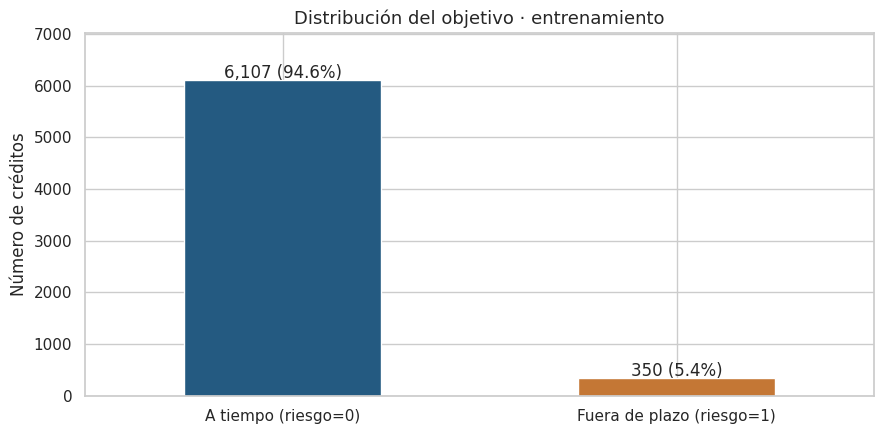

In [3]:
counts = eda.riesgo.value_counts().reindex([0, 1], fill_value=0)
ax = counts.set_axis(["A tiempo (riesgo=0)", "Fuera de plazo (riesgo=1)"]).plot.bar(color=["#245A81", "#C47735"], rot=0)
ax.set(title="Distribución del objetivo · entrenamiento", ylabel="Número de créditos", xlabel="")
for i, value in enumerate(counts):
    ax.text(i, value + 40, f"{value:,} ({value / len(eda):.1%})", ha="center")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout(); plt.show()
print("Tasa de riesgo en entrenamiento:", round(eda.riesgo.mean(), 4))

La clase de riesgo es minoritaria. Accuracy por sí sola puede ocultar que no detectamos pagos fuera de plazo. Compararemos average precision con la prevalencia de la clase y reportaremos precision, recall, F1, F2 y ROC-AUC.

## 3. Calidad de datos antes de limpiar

Edades fuera de 18–100: 60
Ingresos declarados iguales a cero: 11
Puntajes de buró negativos: 1


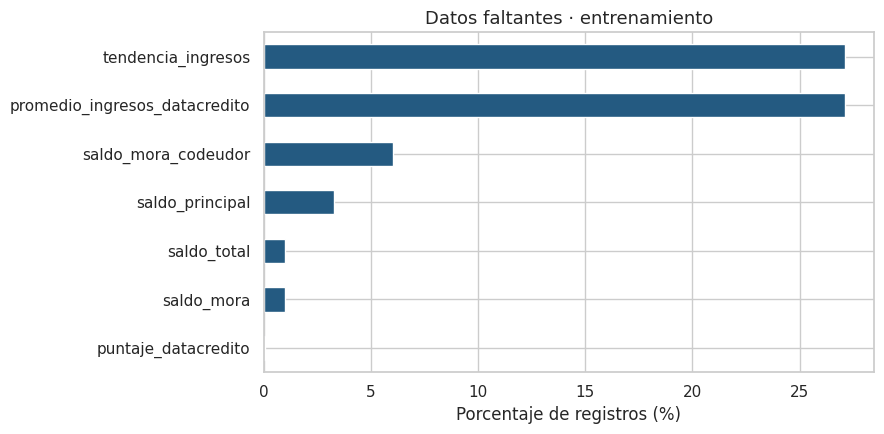

,nulos,porcentaje
puntaje_datacredito,4,0.06
saldo_mora,64,0.99
saldo_total,64,0.99
saldo_principal,212,3.28
saldo_mora_codeudor,390,6.04
promedio_ingresos_datacredito,1750,27.10
tendencia_ingresos,1751,27.12


In [4]:
nulls = eda.isna().mean().mul(100).sort_values()
nulls[nulls > 0].plot.barh(color="#245A81")
plt.title("Datos faltantes · entrenamiento"); plt.xlabel("Porcentaje de registros (%)")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"nulos": eda.isna().sum(), "porcentaje": eda.isna().mean()*100}).query("nulos > 0").round(2))
print("Edades fuera de 18–100:", (~eda.edad_cliente.between(18, 100)).sum())
print("Ingresos declarados iguales a cero:", (eda.salario_cliente == 0).sum())
print("Puntajes de buró negativos:", (eda.puntaje_datacredito < 0).sum())

Los faltantes no se reemplazan automáticamente por cero. Los códigos negativos del buró necesitan un diccionario. Para las variables usadas: edades fuera del rango operativo 18–100 e ingresos cero pasan a faltantes; las medianas se aprenden solo en entrenamiento. Los montos extremos se conservan porque no sabemos si son errores, y se usa escalado robusto.

## 4. Distribuciones de variables numéricas

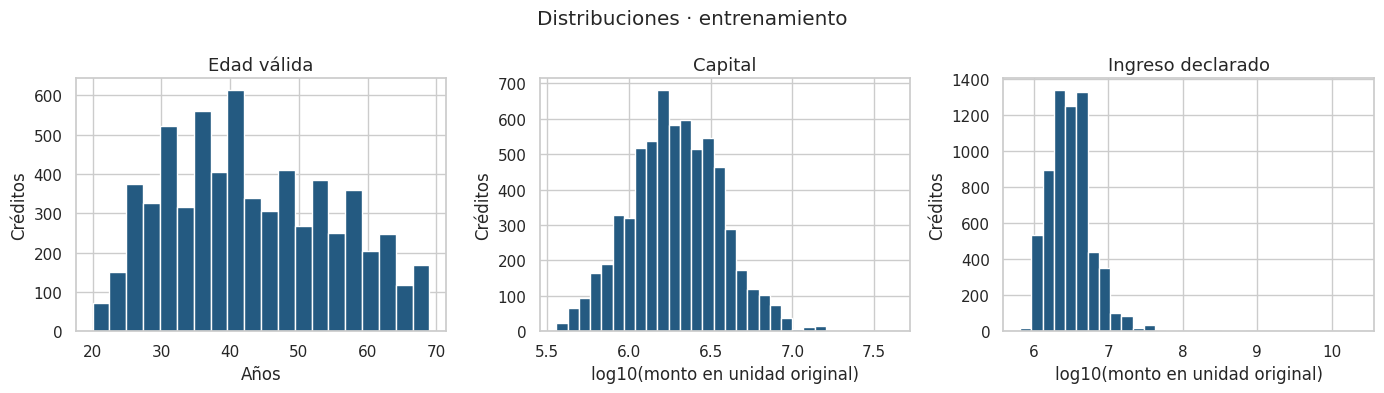

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,cuota_ingreso,capital_ingreso,otros_prestamos_ingreso
count,6457.00,6457.00,6397.00,6.446000e+03,6.457000e+03,6457.00,6446.00,6446.00,6446.00
mean,2383314.05,10.76,43.15,1.399747e+07,3.394840e+06,226419.42,0.07,0.80,0.44
std,1830448.18,5.90,12.00,3.643587e+08,6.830603e+07,193189.89,0.05,0.61,6.24
min,360000.00,2.00,20.00,6.520000e+05,0.000000e+00,23944.00,0.00,0.00,0.00
25%,1258714.80,6.00,33.00,2.000000e+06,5.000000e+05,116650.00,0.04,0.39,0.23
50%,1897171.20,10.00,42.00,3.000000e+06,1.000000e+06,173825.00,0.06,0.65,0.33
75%,2998800.00,12.00,53.00,4.600000e+06,2.000000e+06,266484.00,0.09,1.02,0.47
max,41444152.80,90.00,69.00,2.200000e+10,4.974345e+09,3816752.00,0.59,7.00,500.00


In [5]:
clean = CreditFeatures().transform(eda)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(clean.edad_cliente.dropna(), bins=20, color="#245A81")
axes[0].set(title="Edad válida", xlabel="Años", ylabel="Créditos")
for ax, col, title in [(axes[1], "capital_prestado", "Capital"), (axes[2], "salario_cliente", "Ingreso declarado")]:
    ax.hist(np.log10(clean[col].dropna()), bins=30, color="#245A81")
    ax.set(title=title, xlabel="log10(monto en unidad original)", ylabel="Créditos")
fig.suptitle("Distribuciones · entrenamiento")
plt.tight_layout(); plt.show()
display(clean.select_dtypes("number").describe().round(2))

El logaritmo se usa aquí solo para visualizar montos con mucha dispersión; no se cambia la unidad de los datos guardados. Las medias pueden estar dominadas por los valores extremos: conviene compararlas con las medianas.

## 5. Análisis bivariable: ocupación y riesgo

,creditos,casos_riesgo,tasa_riesgo
tipo_laboral,,,
Empleado,4143,196,0.047309
Independiente,2314,154,0.066551


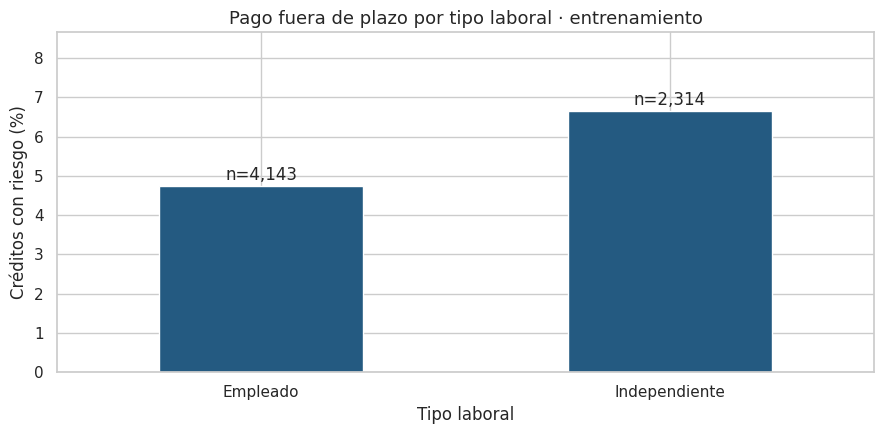

In [6]:
labor = eda.groupby("tipo_laboral").riesgo.agg(["count", "sum", "mean"])
display(labor.rename(columns={"count":"creditos", "sum":"casos_riesgo", "mean":"tasa_riesgo"}))
ax = labor["mean"].mul(100).plot.bar(color="#245A81", rot=0)
ax.set(title="Pago fuera de plazo por tipo laboral · entrenamiento", ylabel="Créditos con riesgo (%)", xlabel="Tipo laboral")
for i, row in enumerate(labor.itertuples()):
    ax.text(i, row.mean*100 + .15, f"n={row.count:,}", ha="center")
ax.set_ylim(0, labor["mean"].max()*100*1.3)
plt.tight_layout(); plt.show()

Estas diferencias son asociaciones observadas, no efectos causales del empleo. Se muestran los tamaños de los grupos para contextualizar la comparación.

## 6. Relaciones entre montos

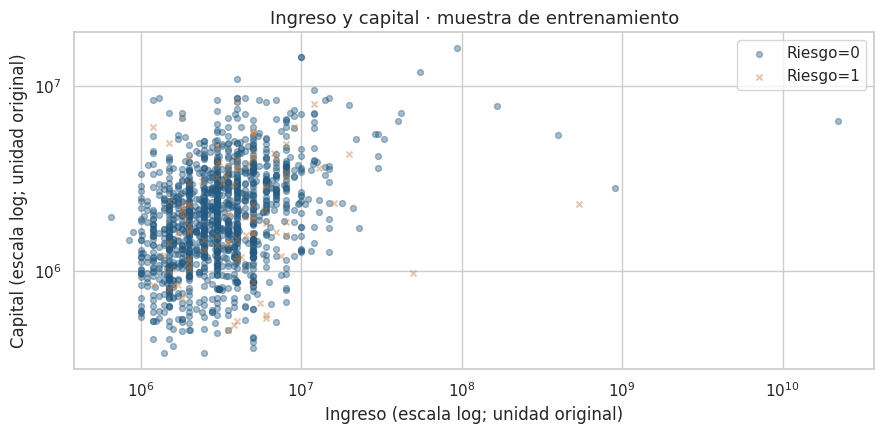

In [7]:
sample = eda.sample(min(1500, len(eda)), random_state=42)
fig, ax = plt.subplots()
for risk, color, marker in [(0, "#245A81", "o"), (1, "#C47735", "x")]:
    rows = sample.loc[(sample.riesgo == risk) & (sample.salario_cliente > 0)]
    ax.scatter(rows.salario_cliente, rows.capital_prestado, alpha=.4, s=18, color=color, marker=marker, label=f"Riesgo={risk}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set(title="Ingreso y capital · muestra de entrenamiento", xlabel="Ingreso (escala log; unidad original)", ylabel="Capital (escala log; unidad original)")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Análisis multivariable

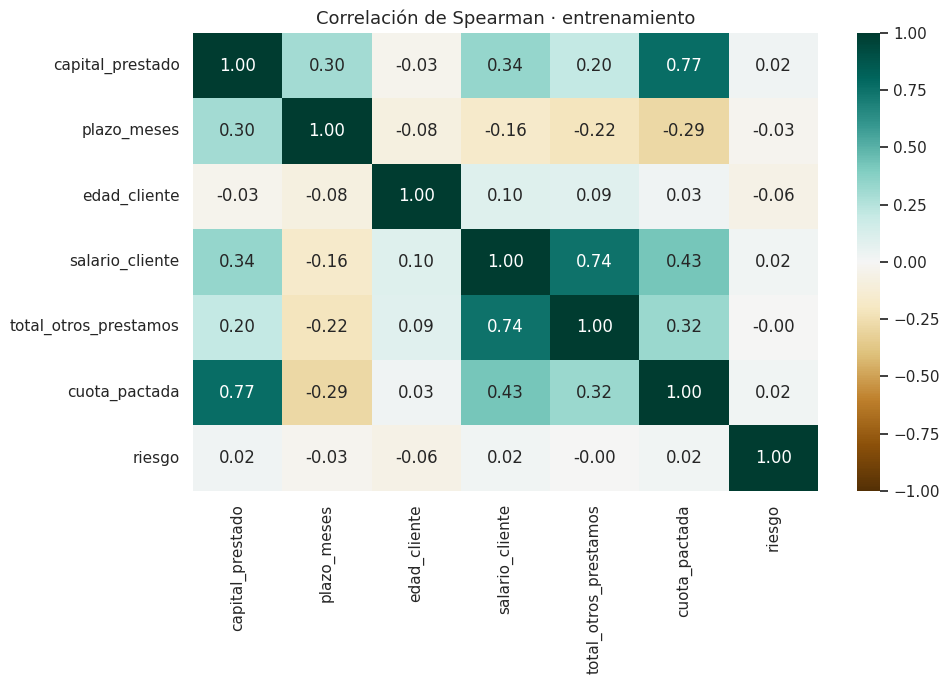

In [8]:
cols = ["capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente", "total_otros_prestamos", "cuota_pactada"]
corr = clean[cols].assign(riesgo=eda.riesgo).corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0, cmap="BrBG", ax=ax)
ax.set_title("Correlación de Spearman · entrenamiento")
plt.tight_layout(); plt.show()

La correlación ayuda a detectar asociaciones y redundancia, pero no demuestra causalidad ni capacidad predictiva fuera de muestra. Las correlaciones se calculan por pares, con los datos disponibles.

## 8. Variables creadas y decisiones

In [9]:
display(clean[["cuota_ingreso", "capital_ingreso", "otros_prestamos_ingreso"]].describe().round(3))
print("Variables originales utilizadas:", FEATURES)

Variables originales utilizadas: ['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'tipo_laboral', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada']


,cuota_ingreso,capital_ingreso,otros_prestamos_ingreso
count,6446.000,6446.000,6446.000
mean,0.072,0.795,0.440
std,0.052,0.610,6.244
min,0.000,0.000,0.000
25%,0.038,0.386,0.229
50%,0.059,0.647,0.333
75%,0.091,1.020,0.467
max,0.588,7.000,500.000


Se crean tres cocientes: cuota/ingreso, capital/ingreso y otros préstamos/ingreso. Si falta ingreso o es cero, el cociente queda nulo y se imputa dentro del pipeline. `tipo_credito` es una categoría, no una escala numérica.

## Conclusiones y siguiente paso
1. El desbalance exige una comparación con un modelo base y métricas de la clase de riesgo.
2. La imputación, codificación y escalado se ajustan dentro de cada fold temporal, evitando aprender estadísticas de validación o test.
3. Se comparan regresión logística y Random Forest en `model_training_evaluation.py`.
4. No hay evidencia suficiente para afirmar que el prototipo pueda usarse en decisiones reales de crédito. Falta validar el objetivo, las unidades, la disponibilidad temporal y la maduración de las etiquetas.
5. Los resultados finales y la matriz de confusión se guardan en `metrics.json` y `evaluation.png`; el README los interpreta después de ejecutar el modelo.